# Parte 5 — Qualidade do detector

Três intensidades, sem retreino, nas mesmas sequências e detecções públicas congeladas. O gerador não usa GT. A comparação com o modelo temporal final é obrigatória; o baseline sozinho não finaliza esta parte.

Parâmetros e comandos estão no README e em `configs/parte5.json`. As intensidades combinam descarte, ruído e FP, portanto não isolam cada causa.

In [1]:
from pathlib import Path
import json
import csv
from IPython.display import display, Image
from parte5 import run

OUTPUT = Path("outputs/parte5")
RUN_STRESS = False
TEMPORAL_PREDICTIONS = None  # pasta com MOT bruto: nivel/seed-N/MOT17-XX.txt
if RUN_STRESS:
    run("data/MOT17", OUTPUT, "configs/parte1.json", "configs/parte5.json", TEMPORAL_PREDICTIONS)
if not (OUTPUT / "results.json").exists():
    raise FileNotFoundError("Execute python parte5.py ou habilite RUN_STRESS.")
results = json.loads((OUTPUT / "results.json").read_text(encoding="utf-8"))
print("Parte 5 completa:", results["complete_part5"])
print(json.dumps(results["stress"], indent=2))

Parte 5 completa: False
{
  "seeds": [
    0,
    1,
    2
  ],
  "levels": {
    "leve": {
      "drop_probability": 0.1,
      "box_noise_fraction": 0.03,
      "false_positives_per_frame": 0.5
    },
    "medio": {
      "drop_probability": 0.3,
      "box_noise_fraction": 0.08,
      "false_positives_per_frame": 1.5
    },
    "forte": {
      "drop_probability": 0.5,
      "box_noise_fraction": 0.15,
      "false_positives_per_frame": 3.0
    }
  }
}


baseline original mAP= 0.3717 IDF1= 0.4595
baseline leve mAP= 0.2764 IDF1= 0.3784
baseline medio mAP= 0.1165 IDF1= 0.1845
baseline forte mAP= 0.0256 IDF1= 0.053


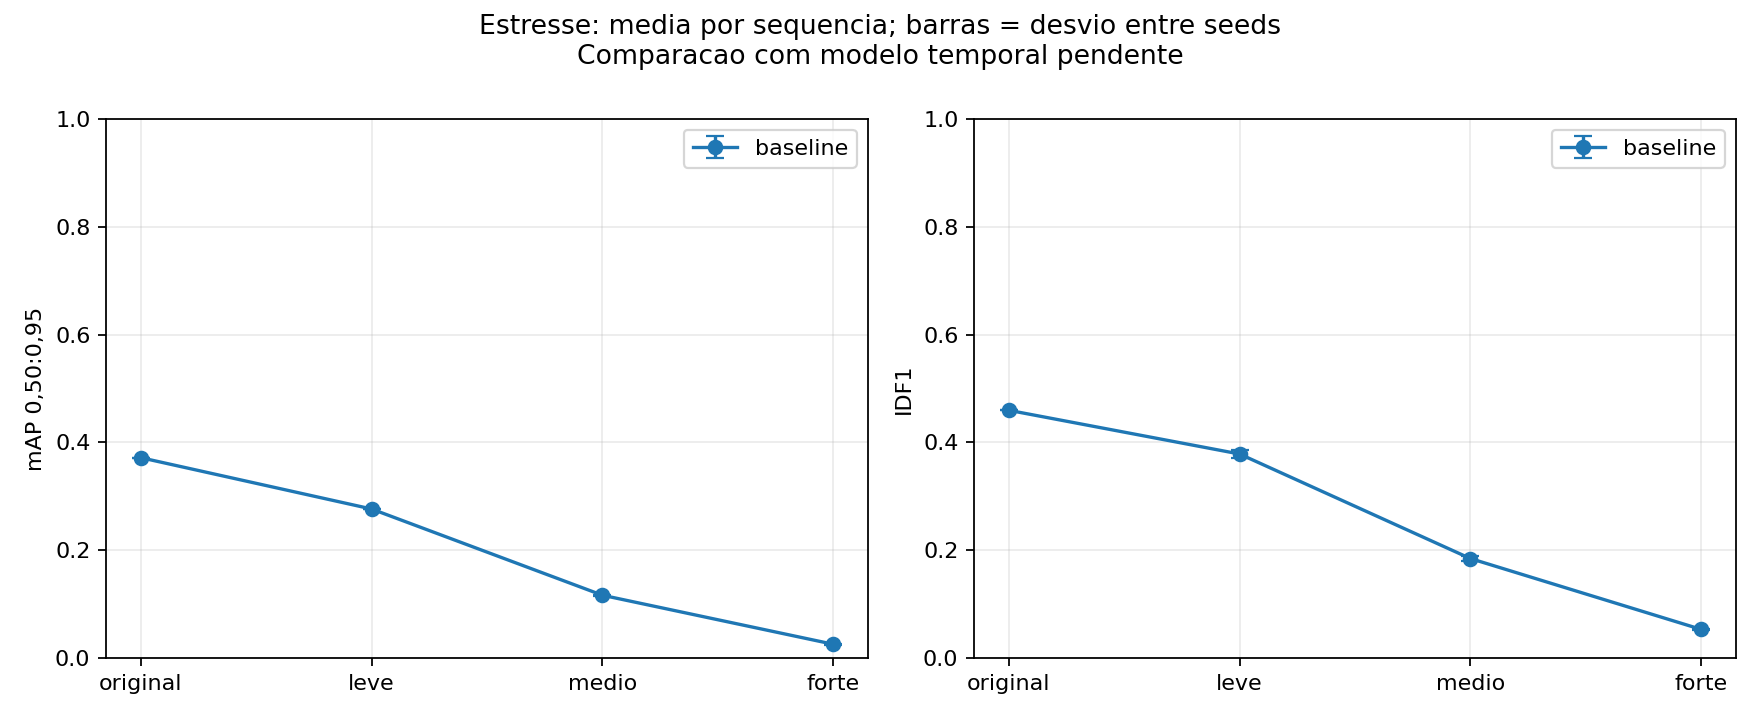

In [2]:
rows = results["results"]
for model in sorted({r["model"] for r in rows}):
    for level in ["original", *results["stress"]["levels"]]:
        selected = [r for r in rows if r["model"] == model and r["level"] == level]
        print(model, level, "mAP=", round(sum(r["map_50_95"] for r in selected)/len(selected), 4),
              "IDF1=", round(sum(r["idf1"] for r in selected)/len(selected), 4))
display(Image(filename=str(OUTPUT / "estresse.png")))

## Interpretação

mAP avalia as entradas espaciais e é compartilhado pelos dois modelos; IDF1 avalia suas identidades. Compare a queda de IDF1 em relação ao controle original de cada modelo para discutir se a recorrência absorve ou amplifica a degradação. Considere também switches, fragmentações e contagem na tabela CSV.

Barras: desvio padrão entre seeds das médias por sequência. Duração completa preservada; quadros sem detecções continuam sendo processados. Sem resultados do checkpoint final, nenhuma conclusão sobre robustez temporal está estabelecida.

### Baseline executado

Médias dos três vídeos e três seeds: original mAP=0,3717 / IDF1=0,4595; leve 0,2764 / 0,3784; médio 0,1165 / 0,1845; forte 0,0256 / 0,0530. A intensidade forte reduz o IDF1 em aproximadamente 88,5% em relação ao controle. Esses valores estabelecem a referência do baseline; falta medir a recorrência final nas mesmas entradas.
